In [15]:
import random
import copy
import matplotlib.pyplot as plt
from src.individuo import Individuo


random.seed(42)



class AlgoritmoGenetico:

    def __init__(self, tampopulacao, L, tamanhos, demandas, nMaxBarras):
        self.tampopulacao = tampopulacao
        self.L = L
        self.tamanhos = tamanhos
        self.demandas = demandas
        self.nMaxBarras = nMaxBarras

        # cria lista expandida de itens
        self.items = []
        for i, d in enumerate(demandas):
            self.items += [i] * d

        self.numGenes = len(self.items)

        # Seleção
        self.pElite = 0.15
        self.pTorneio = 0.5 - self.pElite

        # Histórico para gráfico
        self.historico_fitness = []

    # ============================================================
    def execute(self, iter=10000):

        # inicializa com um pai guloso
        populacao = self.inicializaPopulacao()
        paiGuloso = self.geraIndividuoGuloso()

        # === MELHOR GLOBAL ===
        melhor_global = max(populacao, key=lambda x: x.fitness)
        
        for it in range(iter):
            novapopulacao = []

            for _ in range(self.tampopulacao):

                # Na iteração 0, o pai 1 é sempre o guloso
                if _ == 0:
                    
                    pais = self.selecao(populacao, paiGuloso)
                else:
                    pais = self.selecao(populacao)

                filho = self.cruzamento(pais)
                self.mutacao(filho)
                self.reparar(filho)
                self.fitness(filho)
                novapopulacao.append(filho)

            populacao = novapopulacao

            # Melhor da geração
            melhor = max(populacao, key=lambda x: x.fitness)
            self.historico_fitness.append(melhor.fitness)

            # Atualiza o melhor global 
            if melhor.fitness > melhor_global.fitness:
                melhor_global = copy.deepcopy(melhor)

            # Log
            if (it % 10 == 0) or (it == iter - 1):
                print(f"Iter {it}: melhor fitness = {melhor.fitness:.6f}, barras usadas = {self.conta_barras_usadas(melhor)}")

        print("\n=== MELHOR SOLUÇÃO FINAL (GLOBAL) ===")
        print("Fitness:", melhor_global.fitness)
        print("Barras usadas:", self.conta_barras_usadas(melhor_global))

        # Gera gráficos
        self.plot_fitness()
        self.plot_cortes(melhor_global)

        return melhor_global



    def geraIndividuoGuloso(self):
        # cria vetor genes vazio
        genes = [-1] * self.numGenes

        # itens como pares (tamanho, idx_no_vetor_original)
        itens = [(self.tamanhos[self.items[i]], i) for i in range(self.numGenes)]

        # ordena por tamanho descrescente
        itens.sort(reverse=True)

        consumo = [0] * self.nMaxBarras

        for tam, pos in itens:
            # tenta colocar nas barras
            colocado = False
            for b in range(self.nMaxBarras):
                if consumo[b] + tam <= self.L:
                    consumo[b] += tam
                    genes[pos] = b
                    colocado = True
                    break

            # se não colocou (teoricamente raro)
            if not colocado:
                # joga na primeira barra vazia
                for b in range(self.nMaxBarras):
                    if consumo[b] == 0:
                        consumo[b] += tam
                        genes[pos] = b
                        break
        ind = Individuo(genes=genes)
        ind.fitness = self.fitness(ind) 

        return ind

    def inicializaPopulacao(self):
        populacao = []
        for _ in range(self.tampopulacao):
            ind = Individuo()
            ind.genes = [random.randint(0, self.nMaxBarras - 1) for _ in range(self.numGenes)]
            self.reparar(ind)
            self.fitness(ind)
            populacao.append(ind)
        return populacao
    

    # ============================================================
    def fitness(self, ind: Individuo):
        consumo = [0] * self.nMaxBarras

        for g, item in zip(ind.genes, self.items):
            consumo[g] += self.tamanhos[item]

        for c in consumo:
            if c > self.L:
                ind.fitness = 0.0
                return 0.0

        usadas = sum(1 for c in consumo if c > 0)
        ind.fitness = 1.0 / (1.0 + usadas)
        return ind.fitness

    # ============================================================
    def reparar(self, ind: Individuo):
        """Repara indivíduo movendo itens de barras sobrecarregadas para barras com espaço."""
        consumo = [0] * self.nMaxBarras
        for g, item in zip(ind.genes, self.items):
            consumo[g] += self.tamanhos[item]

        # itera os índices dos genes e garante que nenhum consumo > L ao final
        for i, (g, item_idx) in enumerate(zip(ind.genes, self.items)):
            tam = self.tamanhos[item_idx]
            if consumo[g] > self.L:
                # retira da barra atual
                consumo[g] -= tam
                colocado = False
                # procura uma barra que comporte
                for b in range(self.nMaxBarras):
                    if consumo[b] + tam <= self.L:
                        ind.genes[i] = b
                        consumo[b] += tam
                        colocado = True
                        break
                if not colocado:
                    # se não encontrou (muito improvável com nMaxBarras grande), coloca na barra com menor uso
                    b = min(range(self.nMaxBarras), key=lambda x: consumo[x])
                    ind.genes[i] = b
                    consumo[b] += tam
        return ind

    # ============================================================
    def conta_barras_usadas(self, ind):
        consumo = [0] * self.nMaxBarras
        for g, it in zip(ind.genes, self.items):
            consumo[g] += self.tamanhos[it]
        return sum(1 for c in consumo if c > 0)


    # ============================================================
    def selecao(self, populacao, paiGuloso=None):
        if paiGuloso == None:
            populacaoOrdenada = sorted(populacao, key=lambda x: x.fitness, reverse=True)
            numElite = max(1, int(self.pElite * self.tampopulacao))
            elite = populacaoOrdenada[:numElite]
        else:
            elite = paiGuloso, paiGuloso

        torneioTam = 2
        torneio = random.sample(populacao, torneioTam)
        vencedor = max(torneio, key=lambda x: x.fitness)

        return random.choice(elite), vencedor


    # ============================================================
    def cruzamento(self, pais):
        p = random.randint(1, self.numGenes - 1)
        filho = Individuo()
        filho.genes = pais[0].genes[:p] + pais[1].genes[p:]
        return filho


    # ============================================================
    def mutacao(self, ind, taxa=0.05):
        for i in range(len(ind.genes)):
            if random.random() < taxa:
                ind.genes[i] = random.randint(0, self.nMaxBarras - 1)


    # ============================================================
    def plot_fitness(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.historico_fitness, linewidth=2)
        plt.title("Evolução do Melhor Fitness")
        plt.xlabel("Iteração")
        plt.ylabel("Fitness")
        plt.grid(True)
        plt.show()

    # ============================================================
    def plot_cortes(self, ind: Individuo):
        # Cria estrutura vazia de barras
        barras = [[] for _ in range(self.nMaxBarras)]

        # Coloca cada item na sua barra
        for gene, item in zip(ind.genes, self.items):
            barras[gene].append(self.tamanhos[item])

        # Remove barras vazias
        barras = [b for b in barras if len(b) > 0]

        # === ORDENA TODOS OS CORTES DENTRO DE CADA BARRA ===
        for b in barras:
            b.sort(reverse=True)  # maior -> menor

        # === ORDENA AS BARRAS POR CONSUMO TOTAL (maior primeiro) ===
        barras.sort(key=lambda b: sum(b), reverse=True)

        # ==== PLOT ====
        n = len(barras)
        plt.figure(figsize=(10, max(6, n * 0.25)))

        for idx, barra in enumerate(barras):
            x = 0
            for tamanho in barra:
                plt.barh(idx, tamanho, left=x, edgecolor='black')
                plt.text(x + tamanho / 2, idx, f"{tamanho}",
                        ha='center', va='center', fontsize=8)
                x += tamanho

            # linha limite da barra
            plt.plot([self.L, self.L], [idx - 0.4, idx + 0.4], 'r--')

        plt.title("Gráfico dos cortes por barra (ordenado)")
        plt.xlabel("Comprimento")
        plt.ylabel("Barra")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()




Iter 0: melhor fitness = 0.005348, barras usadas = 186
Iter 10: melhor fitness = 0.005181, barras usadas = 192
Iter 20: melhor fitness = 0.005405, barras usadas = 184
Iter 30: melhor fitness = 0.005236, barras usadas = 190
Iter 40: melhor fitness = 0.005319, barras usadas = 187
Iter 50: melhor fitness = 0.005208, barras usadas = 191
Iter 60: melhor fitness = 0.005376, barras usadas = 185
Iter 70: melhor fitness = 0.005319, barras usadas = 187
Iter 80: melhor fitness = 0.005208, barras usadas = 191
Iter 90: melhor fitness = 0.005102, barras usadas = 195
Iter 100: melhor fitness = 0.005181, barras usadas = 192
Iter 110: melhor fitness = 0.005102, barras usadas = 195
Iter 120: melhor fitness = 0.005076, barras usadas = 196
Iter 130: melhor fitness = 0.005128, barras usadas = 194
Iter 140: melhor fitness = 0.005236, barras usadas = 190
Iter 150: melhor fitness = 0.005525, barras usadas = 180
Iter 160: melhor fitness = 0.005208, barras usadas = 191
Iter 170: melhor fitness = 0.005102, barra

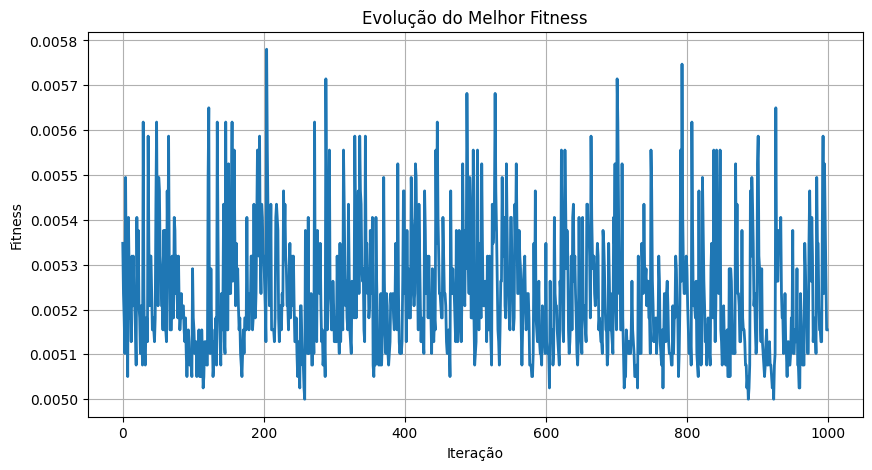

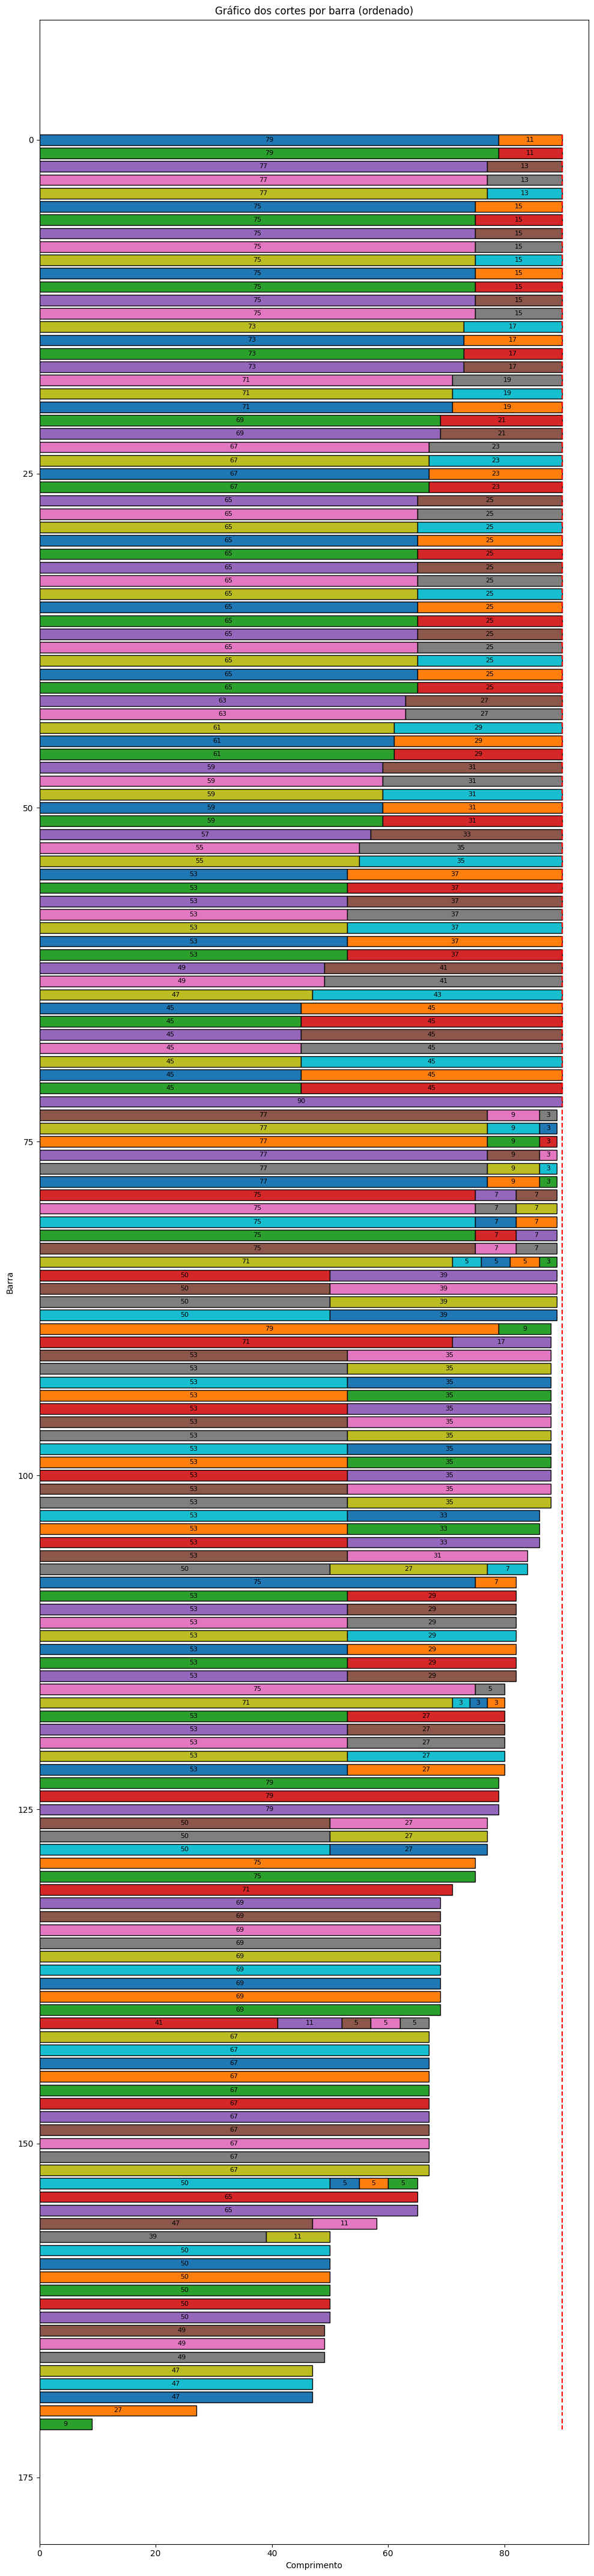

In [16]:

L = 90
tamanhos = [
    3, 5, 7, 9, 11, 13, 15, 17, 19, 21,
    23, 25, 27, 29, 31, 33, 35, 37, 39, 41,
    43, 45, 47, 49, 50, 53, 55, 57, 59, 61,
    63, 65, 67, 69, 71, 73, 75, 77, 79, 90
]

demandas = [
     10, 10, 12, 8, 5, 3, 9, 5, 3, 2,
     4, 15, 12, 10, 6, 4, 14, 7, 5, 3,
     1, 14, 5, 5, 15, 35, 2, 1, 5, 3,
     2, 17, 15, 11, 7, 4, 18, 9, 6, 1
]


nMaxBarras = 300

ga = AlgoritmoGenetico(
    tampopulacao=200,
    L=L,
    tamanhos=tamanhos,
    demandas=demandas,
    nMaxBarras=nMaxBarras
)

melhor = ga.execute(iter=1000)